# Multi-modal Sentiment Classfication

In [1]:
# Data Preparation

In [2]:
pip install kagglehub


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: /Users/evelynchu/.pyenv/versions/clap-env/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("albenft/game-of-thrones-script-all-seasons")

# Print the path
print("Path to dataset files:", path)


Path to dataset files: /Users/evelynchu/.cache/kagglehub/datasets/albenft/game-of-thrones-script-all-seasons/versions/1


In [4]:
pip install pandas


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: /Users/evelynchu/.pyenv/versions/clap-env/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import os

# Load the dataset and List the file
directory = "/Users/evelynchu/.cache/kagglehub/datasets/albenft/game-of-thrones-script-all-seasons/versions/1"
print("Files in directory:")
print(os.listdir(directory))
print("\n")

# Read the csv file 
import pandas as pd

Game_of_Thrones_text = os.path.join(directory, "Game_of_Thrones_Script.csv")
file = pd.read_csv(Game_of_Thrones_text)

# Data exploration
print(file.head())
print("\n")
print(file.info())


Files in directory:
['Game_of_Thrones_Script.csv']


  Release Date    Season    Episode     Episode Title          Name  \
0   2011-04-17  Season 1  Episode 1  Winter is Coming  waymar royce   
1   2011-04-17  Season 1  Episode 1  Winter is Coming          will   
2   2011-04-17  Season 1  Episode 1  Winter is Coming  waymar royce   
3   2011-04-17  Season 1  Episode 1  Winter is Coming          will   
4   2011-04-17  Season 1  Episode 1  Winter is Coming         gared   

                                            Sentence  
0  What do you expect? They're savages. One lot s...  
1  I've never seen wildlings do a thing like this...  
2                             How close did you get?  
3                            Close as any man would.  
4                   We should head back to the wall.  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23911 entries, 0 to 23910
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  -

In [6]:
# Extract all needed text which related to House Lannister

# Drop the uneccessary column
file.drop(columns=['Release Date'], inplace=True)

# filter the row which contain 'Lannister'
lannister_df = file[file['Name'].str.contains('lannister', case=False, na=False)]
print(lannister_df.info())

# Combine all the sentences for House Lannister
lan_text = lannister_df['Sentence'].tolist()
print("\n", lan_text)


<class 'pandas.core.frame.DataFrame'>
Index: 4485 entries, 76 to 23908
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Season         4485 non-null   object
 1   Episode        4485 non-null   object
 2   Episode Title  4485 non-null   object
 3   Name           4485 non-null   object
 4   Sentence       4485 non-null   object
dtypes: object(5)
memory usage: 210.2+ KB
None

 ["As your brother, I feel it's my duty to warn you", 'And you never worry about anything. When we were seven, you jumped off the cliffs as Casterly Rock. One hundred foot drop into the water. And you were never afraid.', "There was nothing to be afraid of until you told father. [In a whisper, mimicking] We're Lannisters. Lannisters don't act like fools.", 'What if Jon Arryn told someone?', 'But who would he tell?', 'My husband.', "If he told the king, both our heads would be skewered on the city gates by now. Whatever Jon Arryn knew or didn'

My project goal is the sentiment classification.
I will focus on the sentiment expression of typical character.
So the whole script is not neccessary, I only need the dialogue of the Lannister family. 

## Part 1 Projection-based Alignment: Text VS Music Sorce

### Sentiment Analysis for Text

In [7]:
# 1. Import necessary libraries
from transformers import pipeline, AutoTokenizer
import numpy as np
from collections import defaultdict

# 2. Load the emotion classification model and tokenizer
classifier = pipeline('text-classification', 
                      model="j-hartmann/emotion-english-distilroberta-base", 
                      top_k=None)
tokenizer = AutoTokenizer.from_pretrained("j-hartmann/emotion-english-distilroberta-base")

# 3. Define function to split long text into manageable chunks
def chunk_text(text, tokenizer, max_len=512, stride=256):
    # First, split the text into approximate character chunks before tokenization
    approx_chunk_size = 2000
    rough_chunks = [text[i:i+approx_chunk_size] for i in range(0, len(text), approx_chunk_size)]
    
    tokenized_chunks = []
    for chunk in rough_chunks:
        tokens = tokenizer.encode(chunk, add_special_tokens=False)
        max_chunk_len = max_len - 2
        
        for i in range(0, len(tokens), stride):
            chunk_tokens = tokens[i:i + max_chunk_len]
            if chunk_tokens:
                chunk_text = tokenizer.decode(chunk_tokens)
                tokenized_chunks.append(chunk_text)
    
    return tokenized_chunks


# 4. Define function to perform emotion analysis on each chunk
def analyze_emotions(text_chunks):
    results = [classifier(chunk)[0] for chunk in text_chunks]
    return results

# 5. Define function to aggregate emotion scores across all chunks
def aggregate_emotions(all_results):
    emotion_scores = defaultdict(list)
    for chunk_result in all_results:
        for item in chunk_result:
            emotion_scores[item['label']].append(item['score'])
    
    avg_emotions = {label: round(np.mean(scores), 4) for label, scores in emotion_scores.items()}
    return dict(sorted(avg_emotions.items(), key=lambda x: x[1], reverse=True))

# 6. Apply to the text

# 6-1: Chunk the long text
long_text = ' '.join(lan_text) 
# Since the tokenizer.encode() requires the input to be a single string.
# So, I need to transform the text into string version.

chunks = chunk_text(long_text, tokenizer)
print(f"Text has been split into {len(chunks)} chunks.")

# For reference, performing emotion analysis on each chunk
results = analyze_emotions(chunks)

# 6-2: Aggregate the emotion results across all chunks
final_emotion_profile = aggregate_emotions(results)
print("\nFinal Aggregated Emotion Profile:")
for emotion, score in final_emotion_profile.items():
    print(f"{emotion}: {score}")

Device set to use mps:0
Token indices sequence length is longer than the specified maximum sequence length for this model (531 > 512). Running this sequence through the model will result in indexing errors


Text has been split into 348 chunks.

Final Aggregated Emotion Profile:
anger: 0.2778
neutral: 0.2355
disgust: 0.2129
fear: 0.1353
sadness: 0.0636
surprise: 0.0538
joy: 0.0211


In [8]:
# For reference, performing emotion analysis on each chunk
results = analyze_emotions(chunks)
print(results[:5])

[[{'label': 'fear', 'score': 0.3998814821243286}, {'label': 'anger', 'score': 0.30594944953918457}, {'label': 'disgust', 'score': 0.11795739084482193}, {'label': 'neutral', 'score': 0.11295364797115326}, {'label': 'sadness', 'score': 0.043442968279123306}, {'label': 'surprise', 'score': 0.01567983254790306}, {'label': 'joy', 'score': 0.0041351099498569965}], [{'label': 'disgust', 'score': 0.47004562616348267}, {'label': 'anger', 'score': 0.28117209672927856}, {'label': 'neutral', 'score': 0.1496502012014389}, {'label': 'sadness', 'score': 0.052289847284555435}, {'label': 'surprise', 'score': 0.02467324212193489}, {'label': 'joy', 'score': 0.012773603200912476}, {'label': 'fear', 'score': 0.009395440109074116}], [{'label': 'neutral', 'score': 0.6291892528533936}, {'label': 'sadness', 'score': 0.15380863845348358}, {'label': 'disgust', 'score': 0.07540594041347504}, {'label': 'anger', 'score': 0.05154314264655113}, {'label': 'surprise', 'score': 0.04918920248746872}, {'label': 'joy', 'sc

In [9]:
pip install matplotlib

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: /Users/evelynchu/.pyenv/versions/clap-env/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


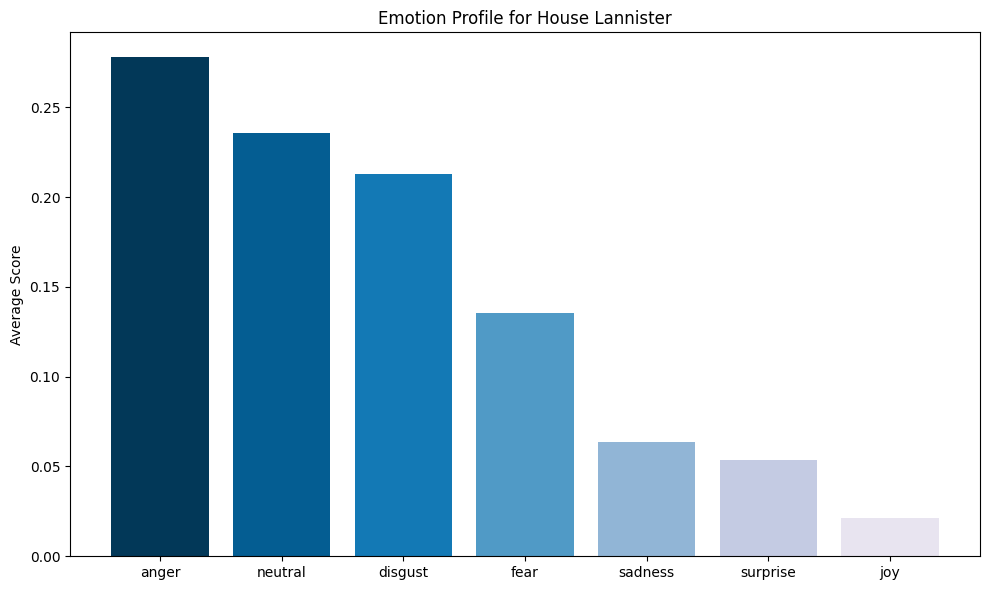

In [10]:
# Visualize the final emotion profile
import matplotlib.pyplot as plt

emotions = list(final_emotion_profile.keys())
scores = list(final_emotion_profile.values())

plt.figure(figsize=(10, 6))

cmap = plt.get_cmap('PuBu')
colors = [cmap(1 - i / len(emotions)) for i in range(len(emotions))]

plt.bar(emotions, scores, color=colors)

plt.title('Emotion Profile for House Lannister')
plt.ylabel("Average Score")
plt.tight_layout()
plt.show()


### Sentiment Analysis for Music Score

In [11]:
pip install music21

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: /Users/evelynchu/.pyenv/versions/clap-env/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
# Import the converter module from music21, which is used for parsing musical files.
from music21 import converter

# Parse the MusicXML file of "The Rains of Castamere" into a music21 score object.
# This loads the full structure of the music including notes, key signatures, and etc.
score = converter.parse('/Users/evelynchu/Desktop/IST 736/Final Project/Music/The rains of Castamere.mxl')

# This shows the hierarchy of musical elements in text format rather than musical format.
# It's mainly used to inspecting the content of the music file.
score.show('text')


{0.0} <music21.text.TextBox '70015'>
{0.0} <music21.text.TextBox '47'>
{0.0} <music21.text.TextBox '51'>
{0.0} <music21.text.TextBox 'The rains ...'>
{0.0} <music21.text.TextBox '4401917'>
{0.0} <music21.metadata.Metadata object at 0x3c83b2d10>
{0.0} <music21.stream.PartStaff P1-Staff1>
    {0.0} <music21.instrument.Piano 'P1: Piano: Acoustic Grand Piano'>
    {0.0} <music21.stream.Measure 1 offset=0.0>
        {0.0} <music21.layout.SystemLayout>
        {0.0} <music21.layout.StaffLayout distance None, staffNumber None, staffSize None, staffLines None>
        {0.0} <music21.clef.TrebleClef>
        {0.0} <music21.key.KeySignature of 1 flat>
        {0.0} <music21.stream.Voice 1>
            {0.0} <music21.note.Note F>
            {1.5} <music21.note.Note A>
            {2.0} <music21.note.Note G>
            {2.5} <music21.note.Note F>
        {0.0} <music21.stream.Voice 6>
            {2.5} <music21.note.Rest eighth>
    {3.0} <music21.stream.Measure 2 offset=3.0>
        {0.0} <musi

In [13]:
# Extract key music features

from music21 import key, tempo, meter, note

# 1. Get mode: Major or Minor
mode = score.analyze('key').mode

# 2. Get tempo
# Tempo reflects emotional intensity.
tempos = score.flat.getElementsByClass(tempo.MetronomeMark)
bpm = tempos[0].number if tempos else None

# 3. Get time signature
ts = score.recurse().getElementsByClass(meter.TimeSignature)
time_signature = ts[0].ratioString if ts else "4/4"

# 4. Get average pitch
# Average pitch reflects the feeling of music are heavier or lighter.
pitches = [n.pitch.midi for n in score.flat.notes if isinstance(n, note.Note)]
avg_pitch = sum(pitches) / len(pitches) if pitches else None

# Print all features
music_feature = {
    "mode": mode,
    "tempo": bpm,
    "avg_pitch": avg_pitch,
    "time_signature": time_signature
}

print(f"Each Music Feature: {music_feature}")


Each Music Feature: {'mode': 'minor', 'tempo': None, 'avg_pitch': 68.98305084745763, 'time_signature': '4/4'}


/Users/evelynchu/.pyenv/versions/clap-env/lib/python3.11/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)


This music is written in a minor key, which usually conveys emotions such as sadness, tension, or introspection.  
There is no explicit tempo marking, suggesting that the pace might be flexible or simply not specified.  
The average pitch centers around a moderately high range, meaning the sound is not too dark but also not overly bright.  
The 4/4 time signature indicates a regular, steady beat that feels natural and common in most popular or cinematic music.

### Build an Emotional Space (valence and arousal) to compare the text and music score

#### V-A Space for Text

In [14]:
# Set weak supervision label for text's valence-arousal mapping
emotion_va = {
    'joy': [0.9, 0.6],
    'anger': [0.2, 0.8],
    'fear': [0.1, 0.9],
    'sadness': [0.1, 0.4], 
    'surprise': [0.6, 0.7],
    'disgust': [0.1, 0.6],
    'neutral': [0.5, 0.5]
}

This label inspired by Russell's Circumplex Model of Affect (1980).  
These mappings provide approximate locations of basic emotions within a two-dimensional emotional space, representing positivity (valence) and intensity (arousal).  
  
Title: A Circumplex Model for Affect  
Author: James A. Russell  
Published Journal: Journal of Personality and Social Psychology  
Year of publication: 1980  
https://www.academia.edu/1970374/A_circumplex_model_of_affect

In [15]:
# Map the predicted emotion distribution to a Valence-Arousal space.
valence = sum(emotion_va[label][0] * score for label, score in final_emotion_profile.items() if label in emotion_va)
arousal = sum(emotion_va[label][1] * score for label, score in final_emotion_profile.items() if label in emotion_va)

lan_text_emotion_vector = {"valence": round(valence, 4), "arousal": round(arousal, 4)}
print(f"Mapped Text Emotion to V-A Space: {lan_text_emotion_vector}")


Mapped Text Emotion to V-A Space: {'valence': 0.2658, 'arousal': 0.6653}


Each emotion's contribution is weighted by its classification score and its predefined VA coordinates.  
The final vector represents the overall emotional position of the text.

#### V-A Space for Music Score

In [16]:
# Emotion mapping rules
valence = 0.3 if mode == 'minor' else 0.7
arousal = 0.6 if bpm and bpm > 90 else 0.3

# Adjust valence based on avg_pitch
if avg_pitch:
    if avg_pitch < 60:
        valence -= 0.05  
    elif avg_pitch > 70:
        valence += 0.05  
# Lower avg pitch means slightly more negative.
# Higher avg pitch means slightly more positive.

# Adjust arousal based on time signature
if time_signature not in ['4/4', '2/4']:
    arousal += 0.1  
# Non-standard meter means slightly more emotional movement.

# Limit valence and arousal within [0, 1] range
valence = min(max(valence, 0), 1)
arousal = min(max(arousal, 0), 1)


To estimate the emotional position of the music in the Valence-Arousal space, a rule-based mapping approach is used.  
First, the mode determines the base valence: minor keys are associated with lower valence (more negative emotions), while major keys correspond to higher valence (more positive emotions).
The tempo is then used to estimate the base arousal: faster tempos (bpm > 90) suggest higher arousal, while slower tempos indicate calmer emotional states.  
  
Additionally, two fine-tuning features are introduced:  
Average pitch (avg_pitch): If the average pitch is low (below 60), the valence is slightly decreased to reflect a darker, heavier emotional tone; if the pitch is high (above 70), the valence is slightly increased, suggesting a lighter, brighter emotional color.  
Time signature (time_signature): If the music uses a non-standard meter (i.e., not 4/4 or 2/4), the arousal is slightly increased, as irregular or compound meters tend to create a sense of emotional movement, instability, or tension.  
  
Finally, valence and arousal values are clamped within the [0,1] range and rounded to four decimal places to ensure consistency.  
This mapping provides a simple yet effective way to project musical characteristics into the V-A emotional space, allowing for further comparison and analysis with textual or multimodal emotional representations.

In [17]:
# Map the predicted emotion distribution to a Valence-Arousal space.
lan_emotion_vector = {
    "valence": valence,
    "arousal": arousal
}

print(f"Mapped Music Score Emotion to V-A Space: {lan_emotion_vector}")


Mapped Music Score Emotion to V-A Space: {'valence': 0.3, 'arousal': 0.3}


#### Comparing the V-A value between text and music score

##### 1. Cosine Similarity

In [18]:
from scipy.spatial.distance import cosine

# Correct variable names for valence-arousal vectors
text_va = [lan_text_emotion_vector["valence"], lan_text_emotion_vector["arousal"]]
music_va = [lan_emotion_vector["valence"], lan_emotion_vector["arousal"]]

# Compute cosine similarity between text and music score emotion vectors
similarity = 1 - cosine(text_va, music_va)
print(f"Text-Music Score Emotional Similarity: {similarity:.4f}")


Text-Music Score Emotional Similarity: 0.9190


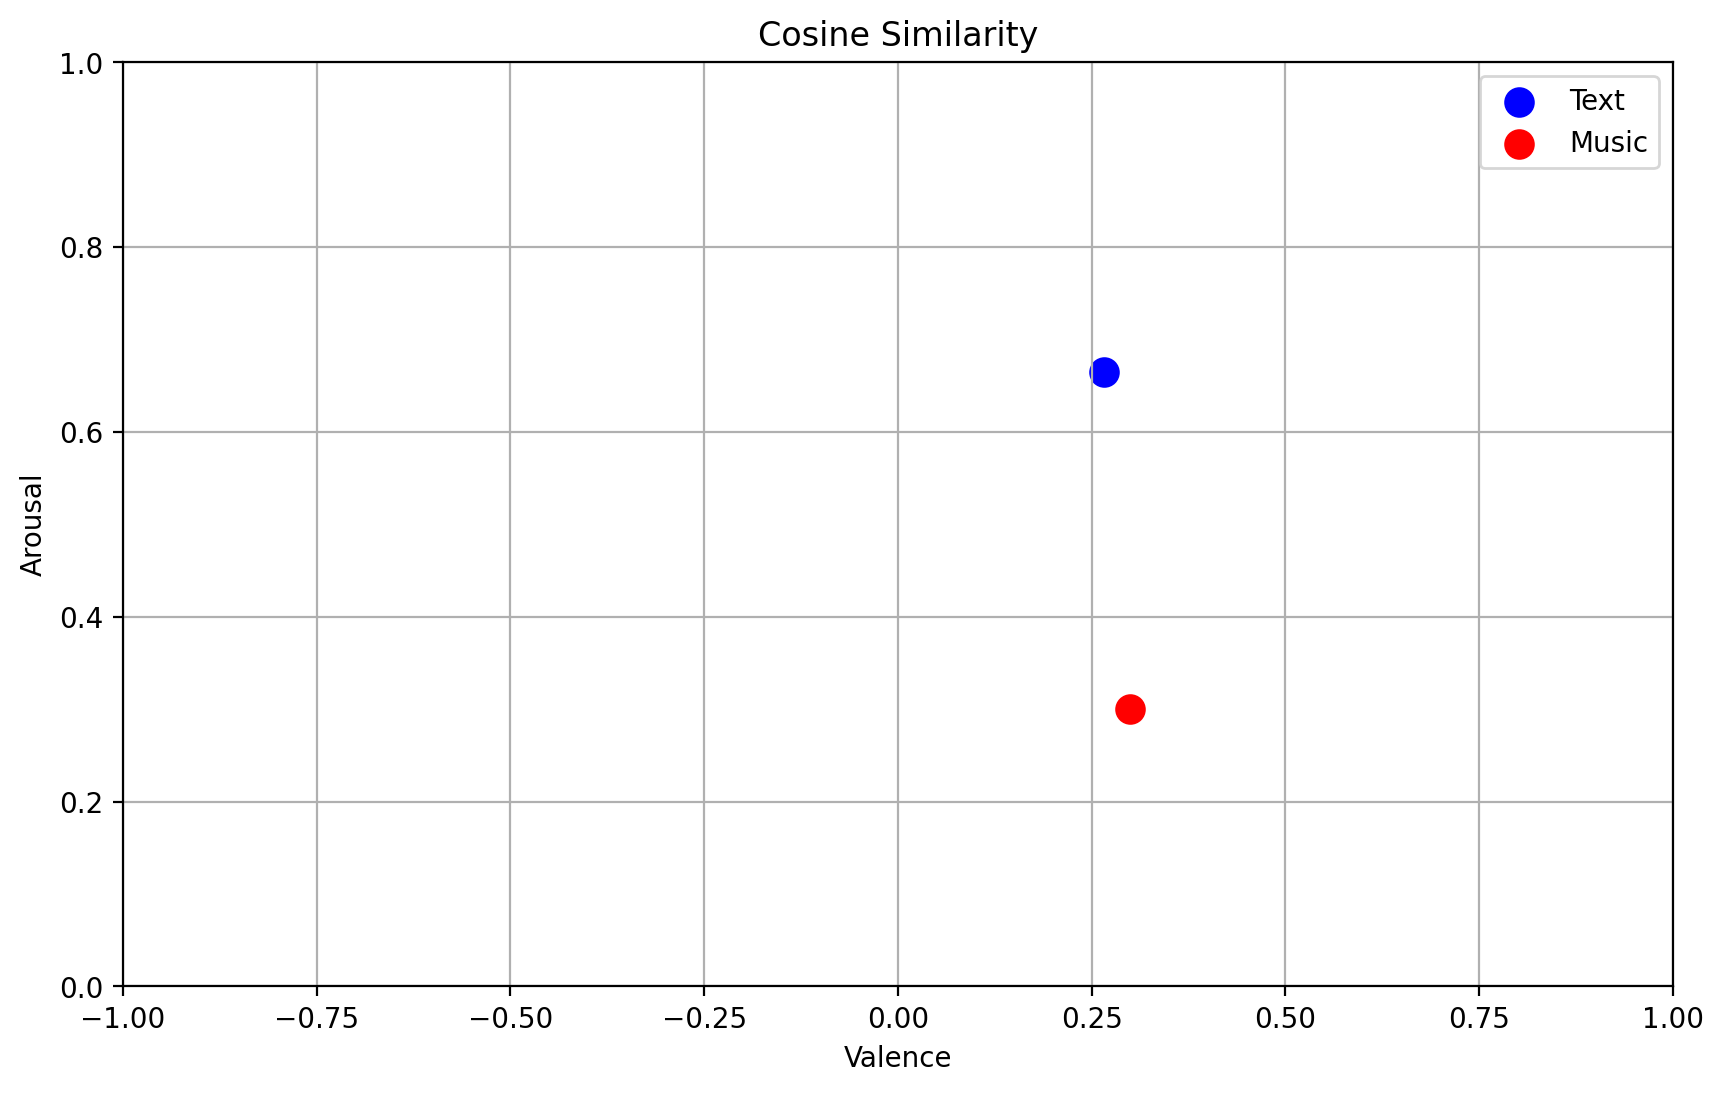

In [19]:
import matplotlib.pyplot as plt

# Visualization: plot both points on Valence-Arousal space
plt.figure(figsize=(10, 6))
plt.scatter(*text_va, label='Text', color='blue', s=100)
plt.scatter(*music_va, label='Music', color='red', s=100)
plt.xlim(-1, 1)
plt.ylim(0, 1)
plt.xlabel('Valence')
plt.ylabel('Arousal')
plt.title('Cosine Similarity')
plt.grid(True)
plt.legend()
plt.show()

The valence-arousal vectors of both Lannister dialogue and its theme music align closely, with a cosine similarity of 0.9190.  
This result confirmed that the soundtrack successfully captures the family's emotional essence: poised, ominous, and quietly brutal.

##### 2. Euclidean Distance

In [20]:
from scipy.spatial.distance import euclidean

# Compute euclidean distance between text and music emotion vectors
distance = euclidean(text_va, music_va)
print(f"Text-Music Emotional Euclidean Distance: {distance:.4f}")

Text-Music Emotional Euclidean Distance: 0.3669


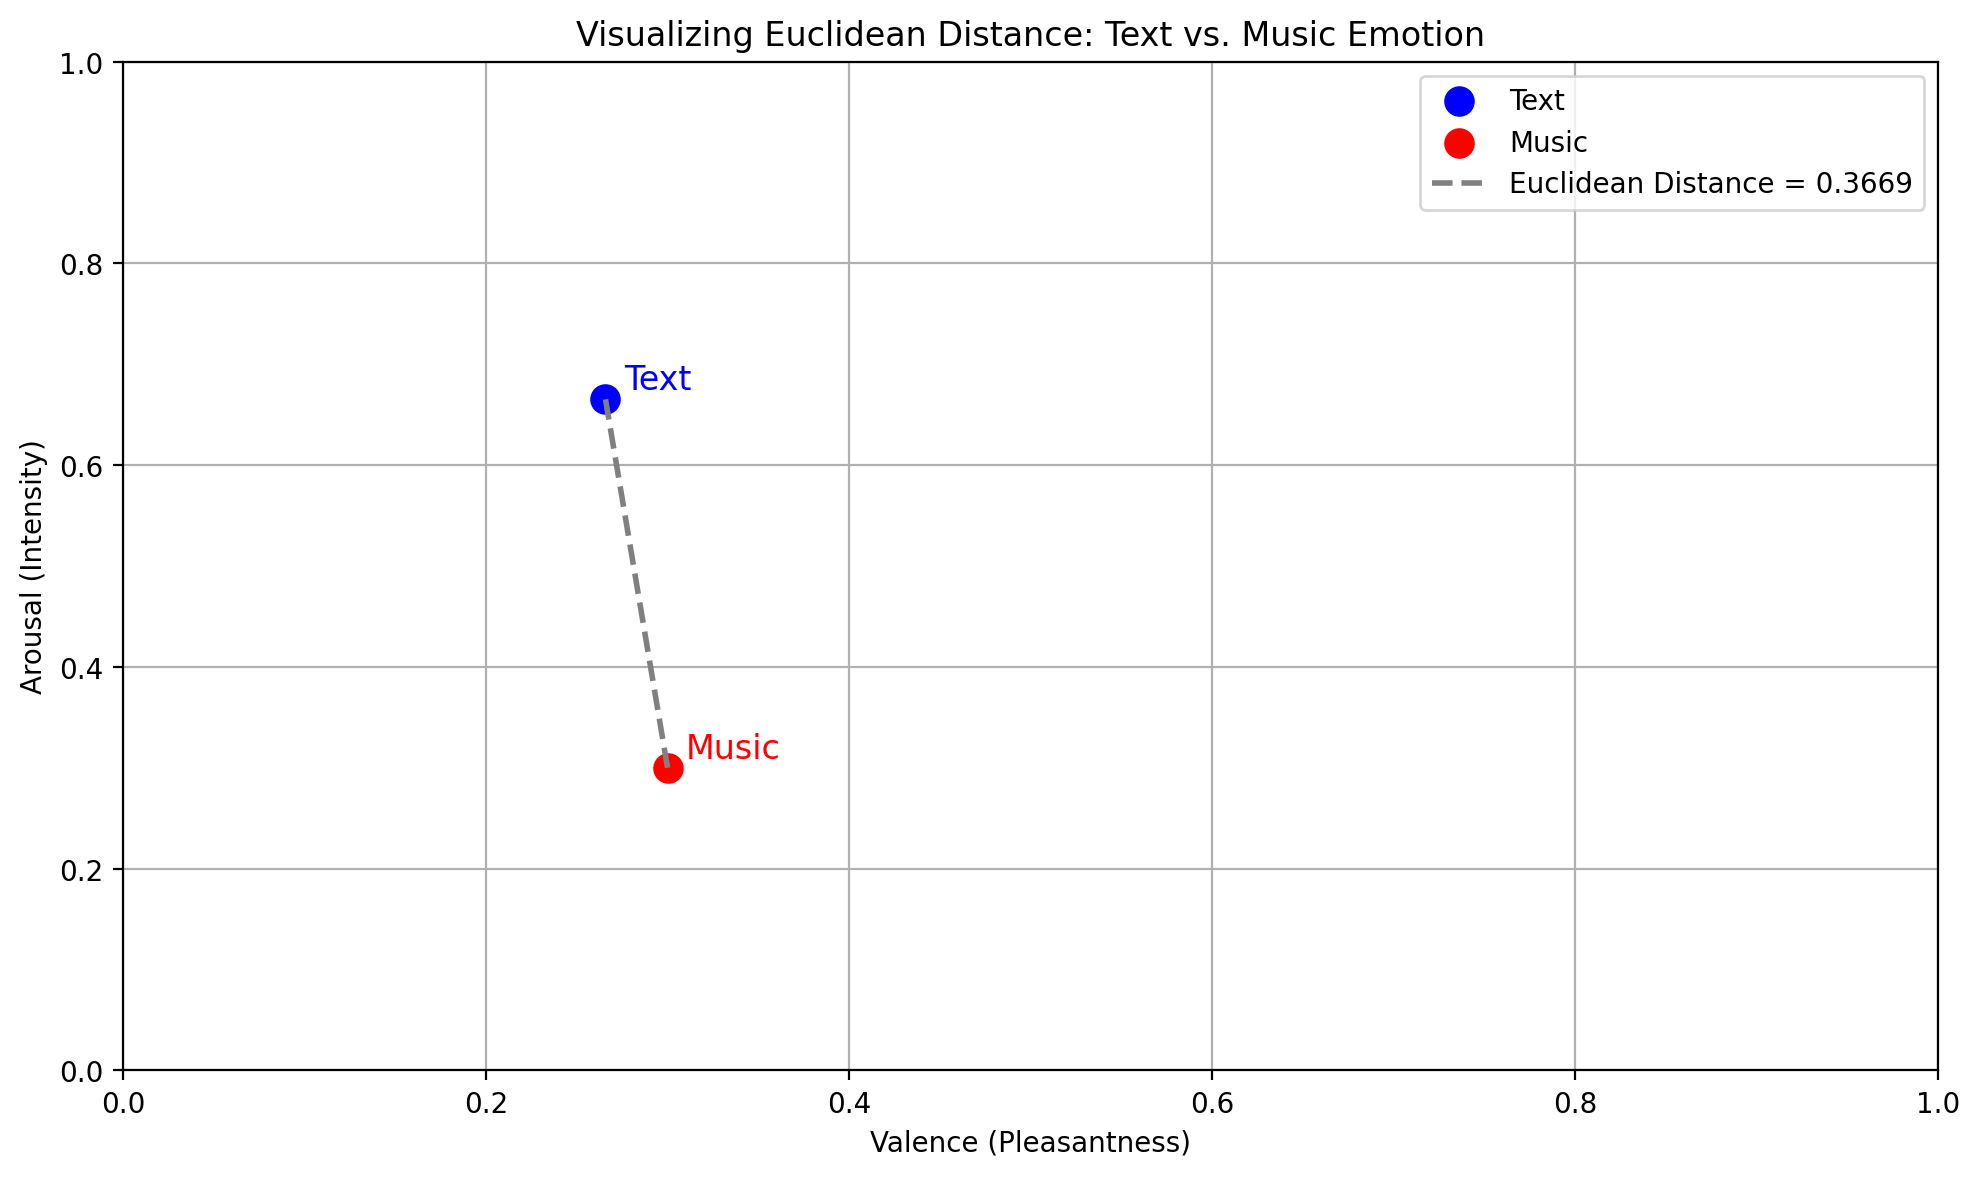

In [21]:
# Visualization: link the euclidean distance between text and music
plt.figure(figsize=(10, 6))
plt.scatter(*text_va, label='Text', color='blue', s=100)
plt.scatter(*music_va, label='Music', color='red', s=100)

plt.plot([text_va[0], music_va[0]], [text_va[1], music_va[1]], 
         linestyle='--', color='gray', linewidth=2, label=f'Euclidean Distance = {distance:.4f}')

plt.text(text_va[0] + 0.01, text_va[1] + 0.01, 'Text', fontsize=12, color='blue')
plt.text(music_va[0] + 0.01, music_va[1] + 0.01, 'Music', fontsize=12, color='red')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Valence (Pleasantness)')
plt.ylabel('Arousal (Intensity)')
plt.title('Visualizing Euclidean Distance: Text vs. Music Emotion')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Although the emotional vectors of the Lannister dialogue and its theme song are not identical in strength (Euclidean Distance = 0.3669), they clearly point in the same emotional direction (Cosine Similarity = 0.9190).  
This suggests that the soundtrack aligns well with the emotional tone of the script, while also offering a slightly restrained, ominous complement to the family's aggressive textual expression.

## Part 2 Embedding-based Alignment: Text VS Audio

### Text

In [22]:
pip install -U sentence-transformers

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: /Users/evelynchu/.pyenv/versions/clap-env/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


#### Sentence Embedding Model 1: all-MiniLM-L6-v2

In [23]:
from sentence_transformers import SentenceTransformer

# Load the first model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode text
text_embeddings1 = model.encode(lan_text, show_progress_bar=True)
print(text_embeddings1[:10])
print("\nShape of embeddings:", text_embeddings1.shape)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Batches:   0%|          | 0/141 [00:00<?, ?it/s]

[[ 0.00495704  0.09584443 -0.01232893 ... -0.0503167  -0.04948319
  -0.07507092]
 [ 0.09375492  0.04331368  0.04097422 ... -0.08485894 -0.08322654
  -0.04718164]
 [ 0.07133347 -0.0471082   0.01475632 ... -0.01400812 -0.02727368
  -0.04882978]
 ...
 [-0.05310024  0.04874133 -0.01361246 ... -0.02689992 -0.09648968
   0.04370341]
 [ 0.00046852  0.17087083  0.04015511 ... -0.02242289 -0.01866134
  -0.05703673]
 [-0.00901318 -0.03471411  0.03269529 ... -0.03455184  0.04064336
  -0.02058968]]

Shape of embeddings: (4485, 384)


In [24]:
from transformers import pipeline

# Load the multi-class emotion analysis pipeline
emotion_analyzer = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=1 
)

# Process in batches for speed and memory efficiency
emotion_labels = []
batch_size = 64

for i in range(0, len(lan_text), batch_size):
    batch = lan_text[i:i+batch_size]
    results = emotion_analyzer(batch)
    for result in results:
        # Handle both list and dict return formats
        if isinstance(result, list):
            label = result[0]['label']
        else:
            label = result['label']
        emotion_labels.append(label)

# Check the first 10 results
for text, label in zip(lan_text[:10], emotion_labels[:10]):
    print(f"{label}: {text}")

# Count the frequency of each emotion label
from collections import Counter
print(Counter(emotion_labels))

Device set to use mps:0


fear: As your brother, I feel it's my duty to warn you
fear: And you never worry about anything. When we were seven, you jumped off the cliffs as Casterly Rock. One hundred foot drop into the water. And you were never afraid.
fear: There was nothing to be afraid of until you told father. [In a whisper, mimicking] We're Lannisters. Lannisters don't act like fools.
anger: What if Jon Arryn told someone?
neutral: But who would he tell?
sadness: My husband.
anger: If he told the king, both our heads would be skewered on the city gates by now. Whatever Jon Arryn knew or didn't know, it died with him. And Robert will choose a new Hand of the king, someone to do his job while he's off fucking boars and hunting whores. Or is it the other way around? And life will go on.
disgust: You should be the Hand of the king.
neutral: That's an honor I can do without. Their days are too long, their lives are too short.
neutral: We've been riding for a month, my love. Surely the dead can wait.
Counter({'ne

In [25]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Suppose these are your features and labels
X = np.array(text_embeddings1)
y = np.array(emotion_labels)

# Split for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       anger       0.50      0.11      0.18       147
     disgust       1.00      0.01      0.02        94
        fear       0.00      0.00      0.00        41
         joy       0.00      0.00      0.00        48
     neutral       0.49      0.99      0.66       423
     sadness       0.00      0.00      0.00        55
    surprise       1.00      0.13      0.24        89

    accuracy                           0.50       897
   macro avg       0.43      0.18      0.16       897
weighted avg       0.52      0.50      0.37       897



/Users/evelynchu/.pyenv/versions/clap-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/evelynchu/.pyenv/versions/clap-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/evelynchu/.pyenv/versions/clap-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

In [26]:
# Apply to all sentences
all_emotion_preds = clf.predict(X)
print(all_emotion_preds[:10])

['fear' 'fear' 'fear' 'anger' 'neutral' 'sadness' 'anger' 'disgust'
 'neutral' 'neutral']


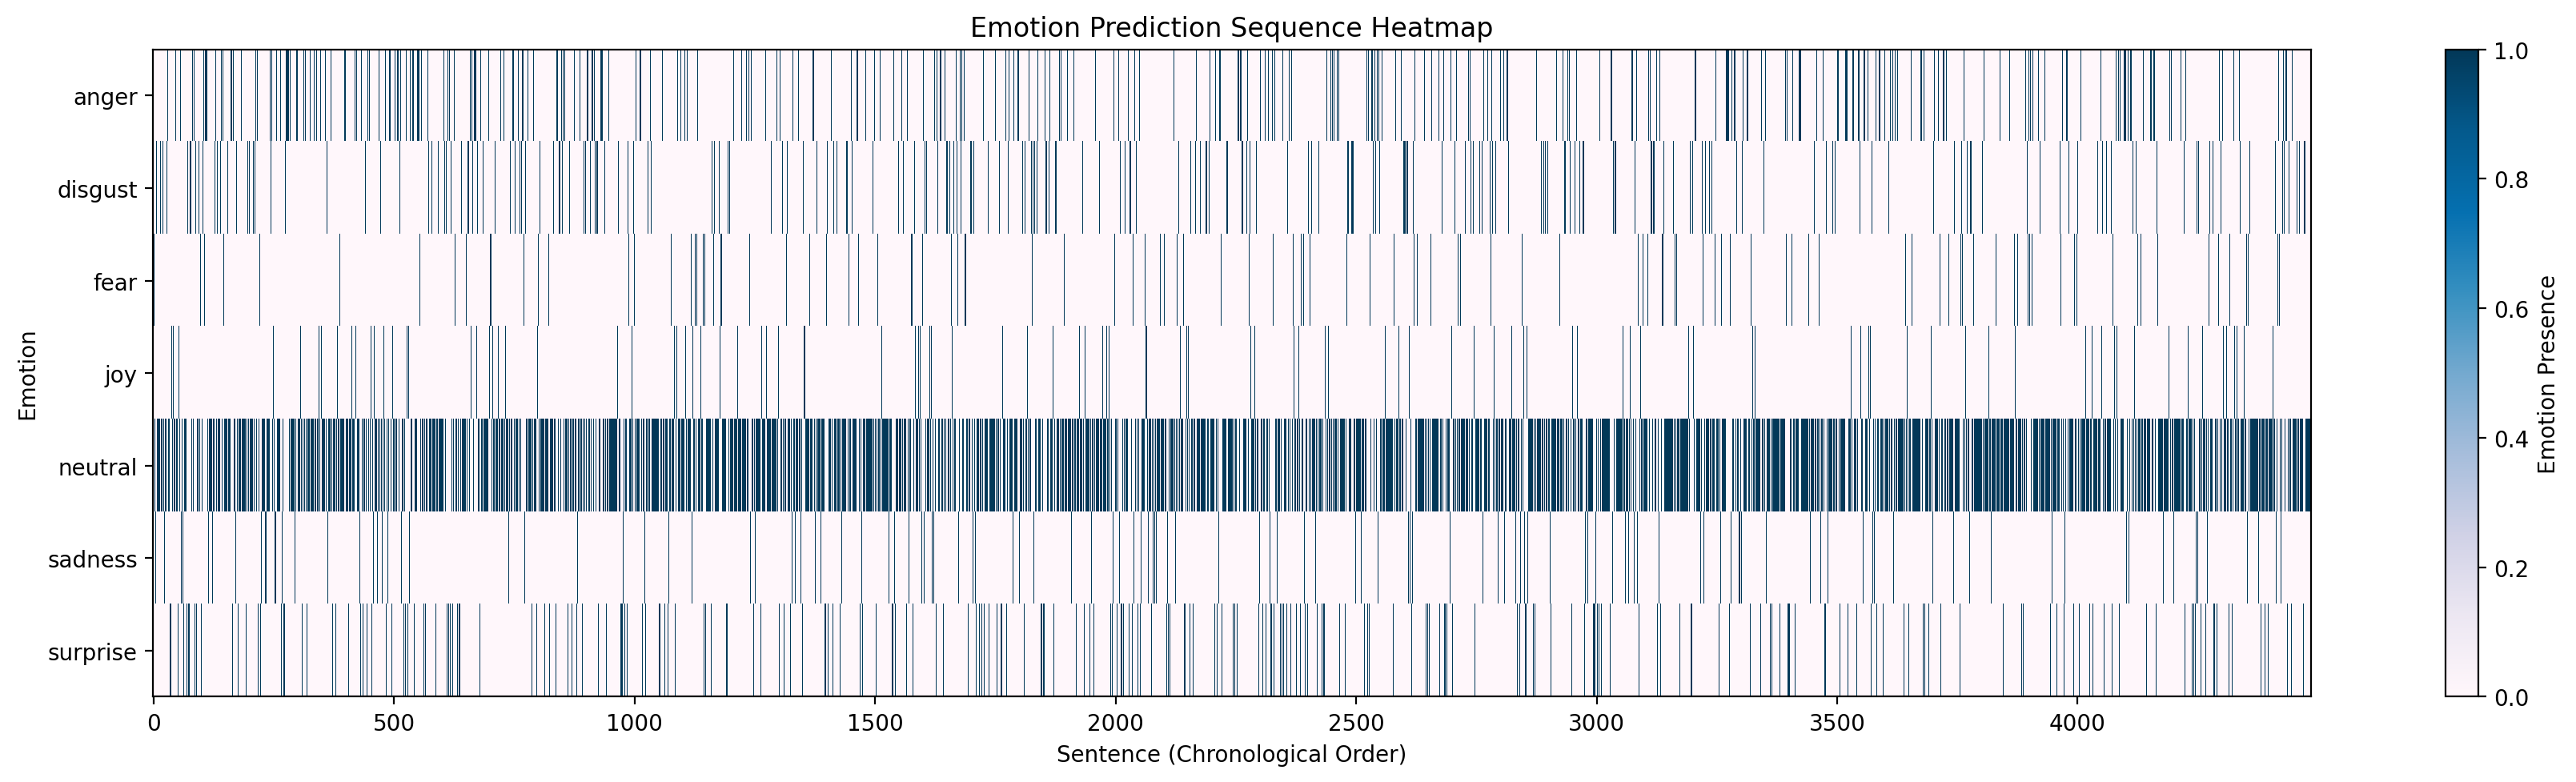

In [27]:
import numpy as np
import matplotlib.pyplot as plt

emotion_classes = sorted(list(set(all_emotion_preds)))
emotion_to_idx = {emo: idx for idx, emo in enumerate(emotion_classes)}
indexed_preds = [emotion_to_idx[label] for label in all_emotion_preds]

heatmap_matrix = np.zeros((len(emotion_classes), len(all_emotion_preds)))
for i, idx in enumerate(indexed_preds):
    heatmap_matrix[idx, i] = 1

plt.figure(figsize=(18, 5))
plt.imshow(heatmap_matrix, aspect='auto', cmap='PuBu', interpolation='nearest')
plt.yticks(range(len(emotion_classes)), emotion_classes)
plt.xlabel("Sentence (Chronological Order)")
plt.ylabel("Emotion")
plt.title("Emotion Prediction Sequence Heatmap")
plt.colorbar(label='Emotion Presence')
plt.tight_layout()
plt.show()


#### Sentence Embedding Model 2: paraphrase-MiniLM-L12-v2

In [28]:
# Load the second moldel
model = SentenceTransformer('paraphrase-MiniLM-L12-v2')

# Encde text
text_embeddings2 = model.encode(lan_text, show_progress_bar=True)
print(text_embeddings2[:10])


Batches:   0%|          | 0/141 [00:00<?, ?it/s]

[[ 0.4361686   0.01410648 -0.0600887  ...  0.2559471  -0.42316353
  -0.2641977 ]
 [ 0.32331526  0.32213107  0.04164213 ...  0.13659763  0.00465168
   0.09822405]
 [ 0.13291183  0.1707346   0.09895514 ...  0.4700982   0.32245502
  -0.08158515]
 ...
 [-0.24758244  0.47304544  0.24854131 ...  0.01586781  0.01094189
  -0.04328575]
 [-0.07421251  0.5392615  -0.0366232  ... -0.34919706 -0.10195435
  -0.18394697]
 [ 0.17134789 -0.13678354 -0.0478171  ... -0.2697855  -0.02959436
  -0.2322475 ]]


In [44]:
from transformers import pipeline

emotion_analyzer = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=1
)

# Batch prediction
emotion_labels = []
batch_size = 64
for i in range(0, len(lan_text), batch_size):
    batch = lan_text[i:i+batch_size]
    results = emotion_analyzer(batch)
    for result in results:
        # Handle both list and dict return types
        if isinstance(result, list):
            label = result[0]['label']
        else:
            label = result['label']
        emotion_labels.append(label)

# Check the first 10 predictions
for text, label in zip(lan_text[:10], emotion_labels[:10]):
    print(f"{label}: {text}")


Device set to use mps:0


fear: As your brother, I feel it's my duty to warn you
fear: And you never worry about anything. When we were seven, you jumped off the cliffs as Casterly Rock. One hundred foot drop into the water. And you were never afraid.
fear: There was nothing to be afraid of until you told father. [In a whisper, mimicking] We're Lannisters. Lannisters don't act like fools.
anger: What if Jon Arryn told someone?
neutral: But who would he tell?
sadness: My husband.
anger: If he told the king, both our heads would be skewered on the city gates by now. Whatever Jon Arryn knew or didn't know, it died with him. And Robert will choose a new Hand of the king, someone to do his job while he's off fucking boars and hunting whores. Or is it the other way around? And life will go on.
disgust: You should be the Hand of the king.
neutral: That's an honor I can do without. Their days are too long, their lives are too short.
neutral: We've been riding for a month, my love. Surely the dead can wait.


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = text_embeddings2
y = emotion_labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       anger       0.53      0.20      0.29       147
     disgust       0.75      0.06      0.12        94
        fear       0.00      0.00      0.00        41
         joy       0.00      0.00      0.00        48
     neutral       0.51      0.98      0.67       423
     sadness       0.00      0.00      0.00        55
    surprise       0.85      0.25      0.38        89

    accuracy                           0.53       897
   macro avg       0.38      0.21      0.21       897
weighted avg       0.49      0.53      0.42       897



/Users/evelynchu/.pyenv/versions/clap-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/evelynchu/.pyenv/versions/clap-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/evelynchu/.pyenv/versions/clap-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

In [ ]:
all_emotion_preds2 = clf.predict(X)
print(all_emotion_preds2[:10])


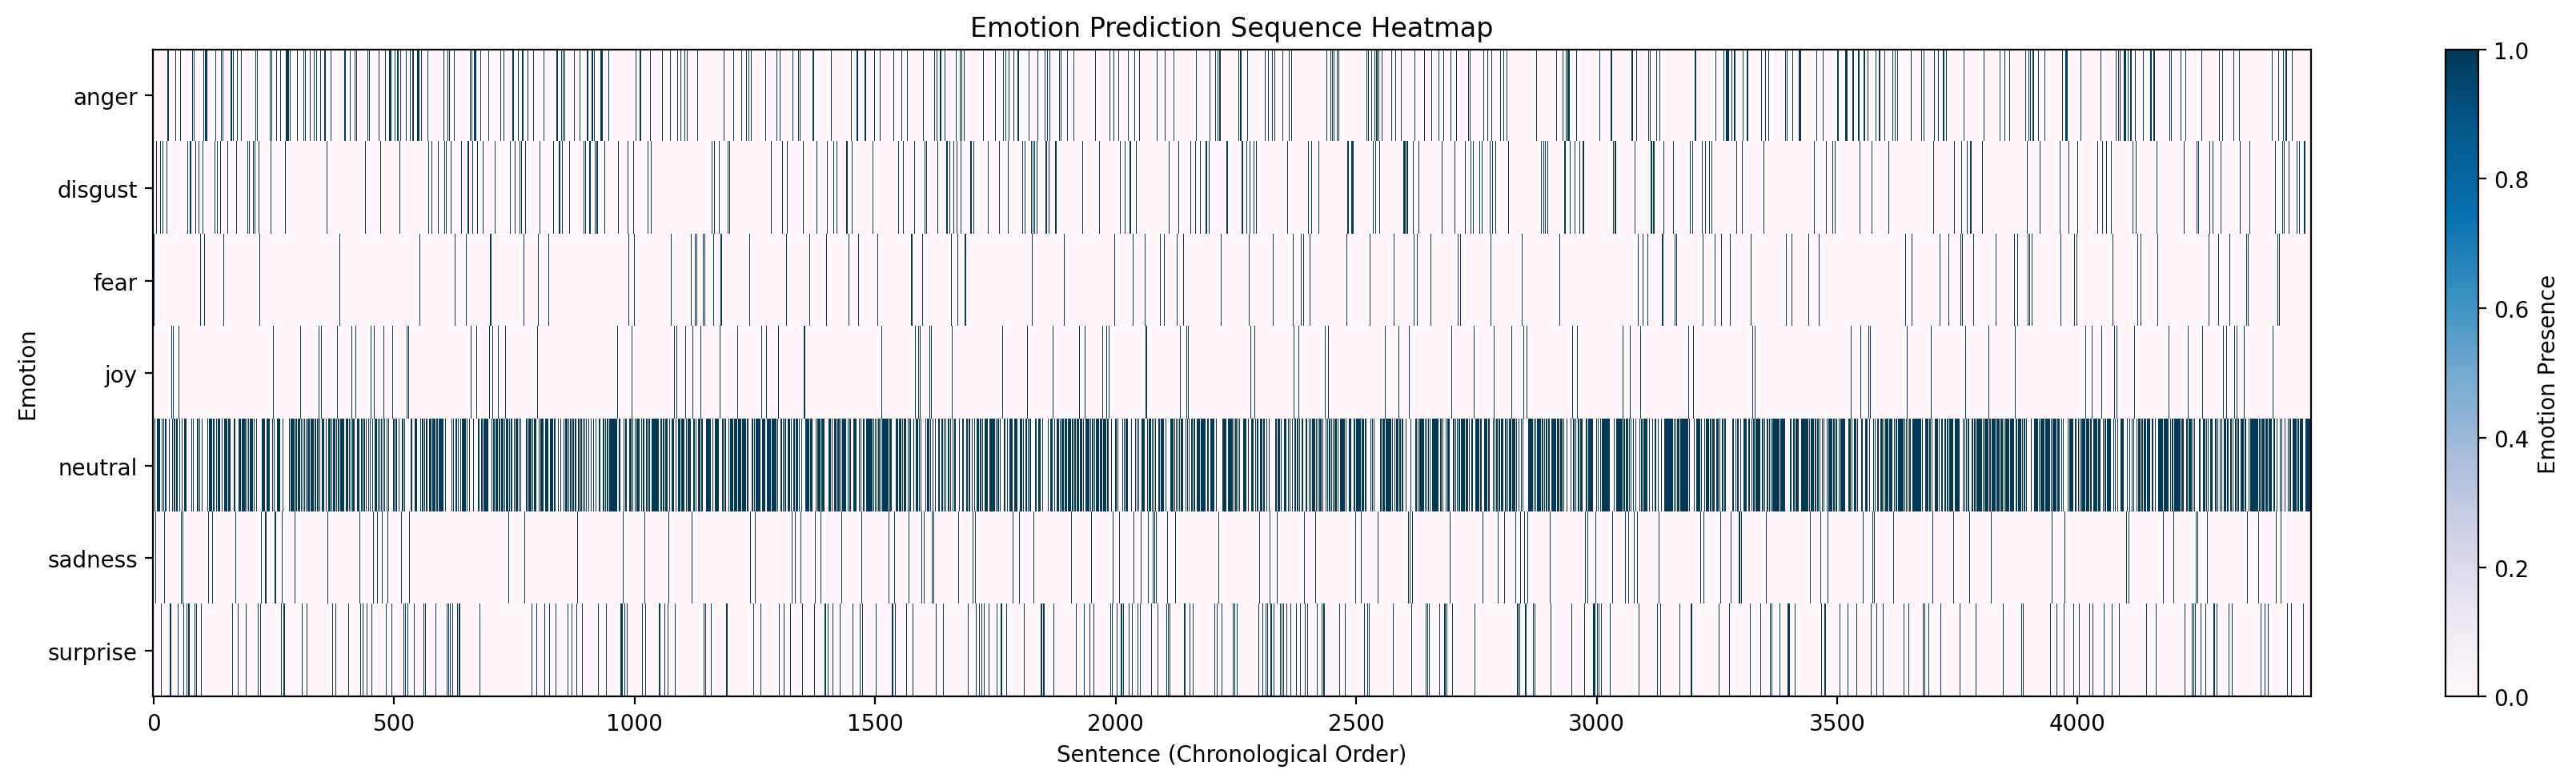

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure all_emotion_preds is a list or np.array of predicted labels in order
emotion_classes = sorted(list(set(all_emotion_preds2)))
emotion_to_idx = {emo: idx for idx, emo in enumerate(emotion_classes)}
indexed_preds = [emotion_to_idx[label] for label in all_emotion_preds2]

# Make a 2D matrix: shape (n_emotions, n_sentences), one-hot encoding
heatmap_matrix = np.zeros((len(emotion_classes), len(all_emotion_preds)))
for i, idx in enumerate(indexed_preds):
    heatmap_matrix[idx, i] = 1

plt.figure(figsize=(18, 5))
plt.imshow(heatmap_matrix, aspect='auto', cmap='PuBu', interpolation='nearest')
plt.yticks(range(len(emotion_classes)), emotion_classes)
plt.xlabel("Sentence (Chronological Order)")
plt.ylabel("Emotion")
plt.title("Emotion Prediction Sequence Heatmap")
plt.colorbar(label='Emotion Presence')
plt.tight_layout()
plt.show()

### Audio

In [2]:
pip install pydub


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: /Users/evelynchu/.pyenv/versions/clap-env/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Transform the audio music format from MP3 to WAV
from pydub import AudioSegment

# Read the MP3 file
mp3_path = "/Users/evelynchu/Desktop/IST 736/Final Project/Music/Game of Thrones - The Rains of Castamere.mp3"
audio = AudioSegment.from_mp3(mp3_path)

# Transform the format
wav_path = "/Users/evelynchu/Desktop/IST 736/Final Project/Music/Game of Thrones - The Rains of Castamere.wav"
audio = audio.set_frame_rate(48000).set_channels(1)
audio.export(wav_path, format="wav")
print(f"WAV file storded into {wav_path}")


WAV file storded into /Users/evelynchu/Desktop/IST 736/Final Project/Music/Game of Thrones - The Rains of Castamere.wav


#### MFCC embedding shape

In [4]:
pip install numpy==1.24.3 --force-reinstall --no-cache-dir


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 13.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
laion-clap 1.1.4 requires numpy==1.23.5, but you have numpy 1.24.3 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 1.24.3 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: /Users/evelynchu/.pyenv/versions/clap-env/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
print(np.__version__)


1.24.3


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import librosa
import numpy as np

# 1. Load and split audio
def load_and_split(audio_path, segment_duration=10, sr=22050):
    y, sr = librosa.load(audio_path, sr=sr)
    segment_samples = segment_duration * sr
    n_segments = len(y) // segment_samples
    mfcc_segments = []
    va_labels = []
    for i in range(n_segments):
        start = i * segment_samples
        end = start + segment_samples
        segment = y[start:end]
        mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=13)
        mfcc = torch.tensor(mfcc.T, dtype=torch.float32)
        mfcc_segments.append(mfcc)
        va_labels.append([0.4, 0.7])  # Example fixed VA label
    return mfcc_segments, va_labels

# 2. Define Dataset
class SegmentDataset(Dataset):
    def __init__(self, mfcc_list, label_list):
        self.mfcc_list = mfcc_list
        self.label_list = label_list

    def __len__(self):
        return len(self.mfcc_list)

    def __getitem__(self, idx):
        return self.mfcc_list[idx], torch.tensor(self.label_list[idx], dtype=torch.float32)

# 3. Collate function
def collate_fn(batch):
    sequences, labels = zip(*batch)
    return pad_sequence(sequences, batch_first=True), torch.stack(labels)

# 4. Define LSTM model
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim=13, hidden_dim=64, output_dim=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])
        

In [15]:
# Apply to my audio data
audio_path = '/Users/evelynchu/Desktop/IST 736/Final Project/Music/Game of Thrones - The Rains of Castamere.wav'

mfcc_segments, va_labels = load_and_split(audio_path, segment_duration=10)

train_dataset = SegmentDataset(mfcc_segments, va_labels)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

# 6. Train LSTM model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMRegressor().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

num_epochs = 30
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss/len(train_loader):.4f}")

# 7. Save model
torch.save(model.state_dict(), 'lstm_va_regressor.pth')
print("Training completed.")


Epoch 1/30 - Train Loss: 0.3326
Epoch 2/30 - Train Loss: 0.0711
Epoch 3/30 - Train Loss: 0.0234
Epoch 4/30 - Train Loss: 0.0217
Epoch 5/30 - Train Loss: 0.0146
Epoch 6/30 - Train Loss: 0.0098
Epoch 7/30 - Train Loss: 0.0065
Epoch 8/30 - Train Loss: 0.0096
Epoch 9/30 - Train Loss: 0.0091
Epoch 10/30 - Train Loss: 0.0067
Epoch 11/30 - Train Loss: 0.0070
Epoch 12/30 - Train Loss: 0.0056
Epoch 13/30 - Train Loss: 0.0042
Epoch 14/30 - Train Loss: 0.0068
Epoch 15/30 - Train Loss: 0.0023
Epoch 16/30 - Train Loss: 0.0017
Epoch 17/30 - Train Loss: 0.0011
Epoch 18/30 - Train Loss: 0.0009
Epoch 19/30 - Train Loss: 0.0008
Epoch 20/30 - Train Loss: 0.0007
Epoch 21/30 - Train Loss: 0.0006
Epoch 22/30 - Train Loss: 0.0005
Epoch 23/30 - Train Loss: 0.0004
Epoch 24/30 - Train Loss: 0.0004
Epoch 25/30 - Train Loss: 0.0003
Epoch 26/30 - Train Loss: 0.0003
Epoch 27/30 - Train Loss: 0.0002
Epoch 28/30 - Train Loss: 0.0002
Epoch 29/30 - Train Loss: 0.0002
Epoch 30/30 - Train Loss: 0.0002
Training completed.

In [37]:
# Load trained model
model = LSTMRegressor().to(device)
model.load_state_dict(torch.load('lstm_va_regressor.pth'))
model.eval()

# Load and split new audio
new_audio_path = '/Users/evelynchu/Desktop/IST 736/Final Project/Music/Game of Thrones - The Rains of Castamere.wav'
mfcc_segments, _ = load_and_split(new_audio_path, segment_duration=10)

# Predict VA for each segment
predicted_va_list = []

with torch.no_grad():
    for mfcc in mfcc_segments:
        mfcc = mfcc.unsqueeze(0).to(device)
        va_pred = model(mfcc)  # output: (1, 2)
        va_pred = va_pred.squeeze(0).cpu().numpy()
        predicted_va_list.append(va_pred)

# Display predictions
for i, va in enumerate(predicted_va_list):
    print(f"Segment {i+1}: Predicted Audio Valence-Arousal = {va}")


Segment 1: Predicted Audio Valence-Arousal = [0.3715582  0.70839995]
Segment 2: Predicted Audio Valence-Arousal = [0.4243971  0.69630593]
Segment 3: Predicted Audio Valence-Arousal = [0.39174962 0.68324953]
Segment 4: Predicted Audio Valence-Arousal = [0.38764626 0.70827794]
Segment 5: Predicted Audio Valence-Arousal = [0.4050697  0.69712776]
Segment 6: Predicted Audio Valence-Arousal = [0.3953988 0.6971276]
Segment 7: Predicted Audio Valence-Arousal = [0.42248327 0.71622455]
Segment 8: Predicted Audio Valence-Arousal = [0.3922332 0.6983561]
Segment 9: Predicted Audio Valence-Arousal = [0.39107496 0.7077038 ]
Segment 10: Predicted Audio Valence-Arousal = [0.4063561  0.70765764]
Segment 11: Predicted Audio Valence-Arousal = [0.3973807 0.6970944]
Segment 12: Predicted Audio Valence-Arousal = [0.39784563 0.7014926 ]
Segment 13: Predicted Audio Valence-Arousal = [0.41000098 0.71026963]
Segment 14: Predicted Audio Valence-Arousal = [0.40228122 0.7012833 ]
Segment 15: Predicted Audio Valence

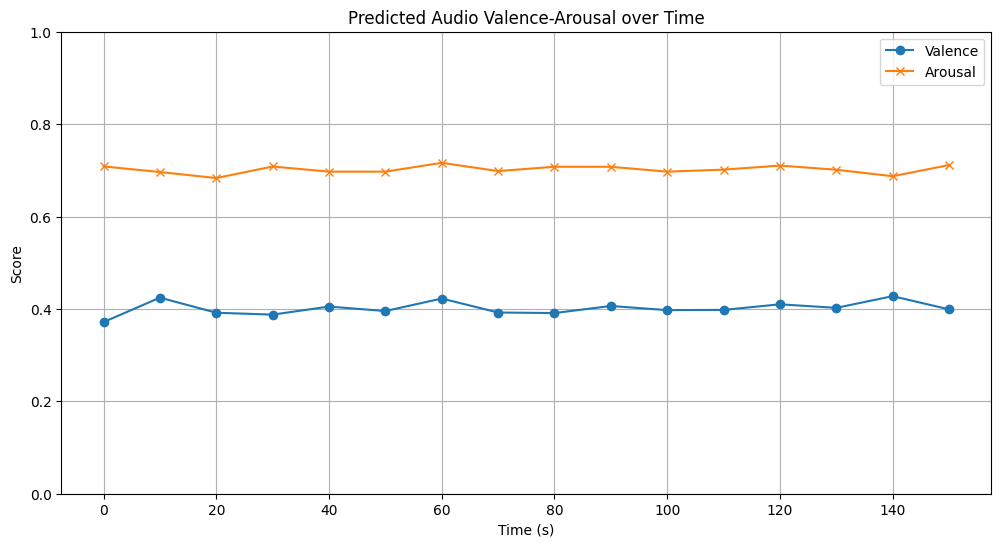

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to numpy array for easier slicing
predicted_va_array = np.array(predicted_va_list)

# Time axis
segment_duration = 10
time_axis = np.arange(len(predicted_va_array)) * segment_duration 

# Plot
plt.figure(figsize=(12, 6))

# Valence curve
plt.plot(time_axis, predicted_va_array[:, 0], label='Valence', marker='o')

# Arousal curve
plt.plot(time_axis, predicted_va_array[:, 1], label='Arousal', marker='x')

plt.xlabel('Time (s)')
plt.ylabel('Score')
plt.title('Predicted Audio Valence-Arousal over Time')
plt.ylim(0, 1)  # Because VA scores are usually between 0~1
plt.grid(True)
plt.legend()
plt.show()


In [46]:
# Define VA ➔ Emotion Label mapping function
def va_to_emotion(valence, arousal):
    if valence >= 0.6 and arousal >= 0.6:
        return "joy"
    elif 0.4 <= valence <= 0.6 and 0.4 <= arousal <= 0.6:
        return "neutral"
    elif valence < 0.4 and arousal < 0.4:
        return "sadness"
    elif valence < 0.4 and arousal >= 0.6:
        return "anger"
    elif valence < 0.4 and 0.4 <= arousal < 0.6:
        return "disgust"
    elif valence < 0.4 and 0.5 <= arousal <= 1.0:
        return "fear"
    elif 0.4 <= valence <= 0.6 and arousal > 0.6:
        return "surprise"
    else:
        return "neutral"

# Map predicted VA to emotion labels
audio_emotion_labels = []

for va in predicted_va_list:
    valence, arousal = va
    label = va_to_emotion(valence, arousal)
    audio_emotion_labels.append(label)

In [47]:
import pandas as pd

# Put results into DataFrame
results_df = pd.DataFrame({
    "Text": lan_text[:len(audio_emotion_labels)],
    "Text_Emotion": emotion_labels[:len(audio_emotion_labels)],
    "Audio_Emotion": audio_emotion_labels
})

# Display first few rows
print(results_df.head())

                                                Text Text_Emotion  \
0   As your brother, I feel it's my duty to warn you         fear   
1  And you never worry about anything. When we we...         fear   
2  There was nothing to be afraid of until you to...         fear   
3                    What if Jon Arryn told someone?        anger   
4                             But who would he tell?      neutral   

  Audio_Emotion  
0         anger  
1      surprise  
2         anger  
3         anger  
4      surprise  


In [48]:
# Calculate matching accuracy
correct = (results_df['Text_Emotion'] == results_df['Audio_Emotion']).sum()
total = len(results_df)
accuracy = correct / total

print(f"Cross-modal Emotion Matching Accuracy: {accuracy*100:.2f}%")

Cross-modal Emotion Matching Accuracy: 12.50%


In [49]:
results_df["Match"] = results_df["Text_Emotion"] == results_df["Audio_Emotion"]
print(results_df)

                                                 Text Text_Emotion  \
0    As your brother, I feel it's my duty to warn you         fear   
1   And you never worry about anything. When we we...         fear   
2   There was nothing to be afraid of until you to...         fear   
3                     What if Jon Arryn told someone?        anger   
4                              But who would he tell?      neutral   
5                                         My husband.      sadness   
6   If he told the king, both our heads would be s...        anger   
7                 You should be the Hand of the king.      disgust   
8   That's an honor I can do without. Their days a...      neutral   
9   We've been riding for a month, my love. Surely...      neutral   
10    Where is our brother? Go find the little beast.      neutral   
11  Mmh. It is true what they say about the Northe...      disgust   
12                   I did hear something about that.      neutral   
13                  

In [49]:
results_df["Match"] = results_df["Text_Emotion"] == results_df["Audio_Emotion"]
print(results_df)

                                                 Text Text_Emotion  \
0    As your brother, I feel it's my duty to warn you         fear   
1   And you never worry about anything. When we we...         fear   
2   There was nothing to be afraid of until you to...         fear   
3                     What if Jon Arryn told someone?        anger   
4                              But who would he tell?      neutral   
5                                         My husband.      sadness   
6   If he told the king, both our heads would be s...        anger   
7                 You should be the Hand of the king.      disgust   
8   That's an honor I can do without. Their days a...      neutral   
9   We've been riding for a month, my love. Surely...      neutral   
10    Where is our brother? Go find the little beast.      neutral   
11  Mmh. It is true what they say about the Northe...      disgust   
12                   I did hear something about that.      neutral   
13                  

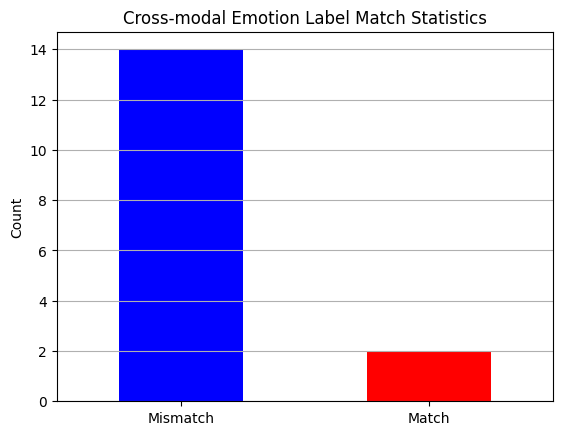

In [52]:
match_counts = results_df["Text_Emotion"] == results_df["Audio_Emotion"]
match_stats = match_counts.value_counts().rename({True: "Match", False: "Mismatch"})

match_stats.plot(kind='bar', color=["blue", "red"])
plt.title("Cross-modal Emotion Label Match Statistics")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


<Figure size 1200x800 with 0 Axes>

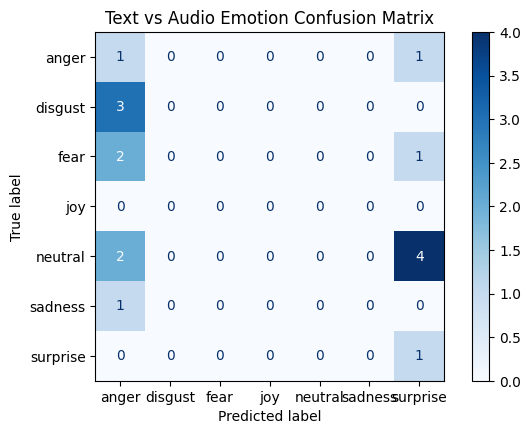

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

results_df['Text_Emotion'] = results_df['Text_Emotion'].str.strip().str.lower()
results_df['Audio_Emotion'] = results_df['Audio_Emotion'].str.strip().str.lower()

emotion_labels_all = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

cm = confusion_matrix(results_df["Text_Emotion"], results_df["Audio_Emotion"], labels=emotion_labels_all)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_labels_all)
plt.figure(figsize=(12, 8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Text vs Audio Emotion Confusion Matrix")
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()
